In [39]:
%pip install openai jieba

You should consider upgrading via the '/Users/danilkladnitsky/.pyenv/versions/3.10.4/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import openai
import requests

class LLMWrapper:
    def __init__(self, provider, **kwargs):
        self.provider = provider.lower()
        
        if self.provider == 'openai':
            self.api_key = kwargs.get("api_key")
            self.model = kwargs.get("model", "gpt-4-mini")
            self.temperature = kwargs.get("temperature", 0.7)
            self.openai_client = openai.OpenAI(api_key=self.api_key, base_url="https://gptunnel.ru/v1")
        
        elif self.provider == 'ollama':
            self.model = kwargs.get("model", "llama3")
            self.temperature = kwargs.get("temperature", 0.7)
            self.ollama_url = kwargs.get("url", "http://localhost:11434/api/generate")
        
        else:
            raise ValueError(f"Unsupported provider: {self.provider}")
    
    def generate(self, prompt):
        if self.provider == 'openai':
            return self._generate_openai(prompt)
        elif self.provider == 'ollama':
            return self._generate_ollama(prompt)
    
    def _generate_openai(self, prompt):
        response = self.openai_client.chat.completions.create(
            model=self.model,
            messages=[{"role": "user", "content": prompt}],
            temperature=self.temperature,
        )
        return response.choices[0].message.content.strip()
    
    def _generate_ollama(self, prompt):
        payload = {
            "model": self.model,
            "prompt": prompt,
            "temperature": self.temperature,
            "stream": False
        }
        response = requests.post(self.ollama_url, json=payload)
        response.raise_for_status()
        return response.json()["response"].strip()

### Models

### Deepseek
DeepSeek R1 (deepseek-r1:1.5b) -> 1.1GB

### Qwen
Qwen3 (qwen3:1.7b) -> 1.4GB

Qwen3 (qwen3:0.6b) -> 523MB

Qwen2.5 (qwen2.5:0.5b) -> 398MB

### OpenAI
GPT 4.1 mini

In [10]:
# OpenAI
llm_openai_4_1 = LLMWrapper(
    provider="openai",
    api_key="shds-JsXijuxs5A2vXBKxEmJlQlLESX4",
    model="gpt-4.1"
)

llm_openai_4_1_mini = LLMWrapper(
    provider="openai",
    api_key="shds-JsXijuxs5A2vXBKxEmJlQlLESX4",
    model="gpt-4.1-mini"
)

# Deepseek
deepseek_r1 = LLMWrapper(
    provider="ollama",
    model="deepseek-r1:1.5b"
)

# Ollama
qwen3_1_7b = LLMWrapper(
    provider="ollama",
    model="qwen3:1.7b"
)


qwen3_0_6b = LLMWrapper(
    provider="ollama",
    model="qwen3:0.6b"
)

qwen2_5_0_5b = LLMWrapper(
    provider="ollama",
    model="qwen2.5:0.5b"
)


## Benchmarks

In [5]:
import jieba

hsk1_vocabulary_path = "datasets/hsk1-vocab.txt"

hsk_vocabulary = open(hsk1_vocabulary_path).read().splitlines()

special_chars = ["。", ",", "，", "！", "？", "：", "；", "、", " ", ""]
vocabulary_map = {word: i for i, word in enumerate(hsk_vocabulary)}
vocabulary_map.update({char: i for i, char in enumerate(special_chars)})

def calculate_word_usage(word: str, sentence: str) -> float:
    if word in sentence:
        return 1.0
    
    return 0.0

def calculate_hsk_vocabulary_coverage(sentence: str) -> float:
    sentence_words = jieba.lcut(sentence.strip())

    score = 0
    for word in sentence_words:
        if word in vocabulary_map:
            score += 1
        else:
            word_len = len(word)
            if word_len == 1:
                score += 0.0
            else:
                characters = list(word)
                for char in characters:
                    if char in vocabulary_map:
                        score += 1 / word_len
                    else:
                        score += 0.0
    
    return score / len(sentence_words)

print(calculate_word_usage("医院", "我在这家医院出生。"))
print(calculate_word_usage("你好", "我在这家医院出生。"))
print(calculate_hsk_vocabulary_coverage("我在这家医院出生缺点。"))
print(calculate_hsk_vocabulary_coverage("我今天去了学校。"))

1.0
0.0
0.7857142857142857
1.0


In [6]:
INPUT_PATH = "datasets/hsk1_prompts.jsonl"
OUTPUT_PATH = "datasets/hsk1_prompts_rewritten.jsonl"

new_dataset = []

with open(INPUT_PATH, "r", encoding="utf-8") as f:
    for line in f:
        data = json.loads(line)
        word = data["word"]
        new_prompt = f"请用词语“{word}”造一个句子，只使用 HSK 1 级词汇，并且只写一句话。"
        new_entry = {
            "word": word,
            "prompt": new_prompt,
            "completion": data["completion"]
        }
        new_dataset.append(new_entry)

with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    for item in new_dataset:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print(f"Rewritten dataset saved to {OUTPUT_PATH}")

NameError: name 'json' is not defined

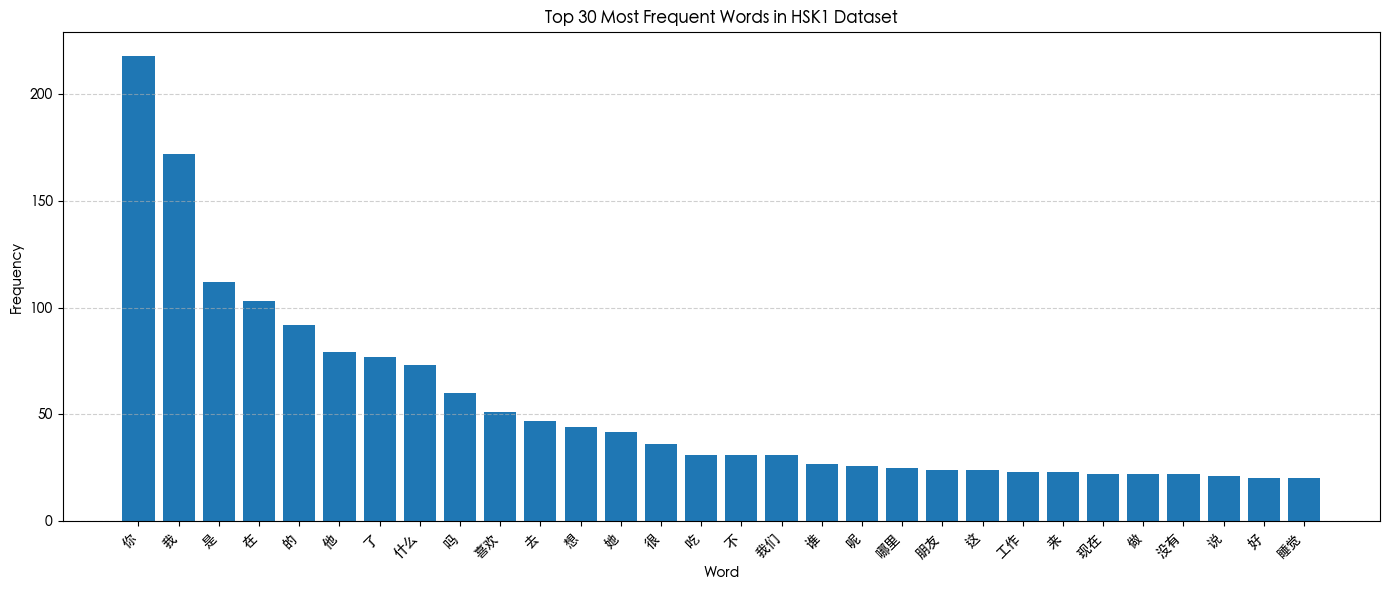

In [7]:
import json
import matplotlib
import matplotlib.pyplot as plt
from collections import Counter
import platform
# Set font to a Chinese-compatible one
if platform.system() == "Windows":
    matplotlib.rcParams['font.family'] = 'Microsoft YaHei'
elif platform.system() == "Darwin":  # macOS
    matplotlib.rcParams['font.family'] = 'Heiti TC'
else:  # Linux (assumes SimHei is installed)
    matplotlib.rcParams['font.family'] = 'SimHei'

# Ensure minus sign is shown properly
matplotlib.rcParams['axes.unicode_minus'] = False

# === Path to your dataset file ===
DATASET_PATH = "datasets/hsk1.dataset.jsonl"

# === Read and count word frequencies ===
word_map = {}

with open(DATASET_PATH, "r", encoding="utf-8") as f:
    for line in f:
        data = json.loads(line)
        word = data["word"]
        word_map[word] = word_map.get(word, 0) + 1

# === Get top 30 words ===
top_words = Counter(word_map).most_common(30)
words, frequencies = zip(*top_words)

# === Plot using matplotlib ===
plt.figure(figsize=(14, 6))
plt.bar(words, frequencies)
plt.title("Top 30 Most Frequent Words in HSK1 Dataset")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


In [13]:
import re
from datetime import datetime

def remove_think_tags(text):
    """
    Removes all content between <think> and </think> tags, including the tags themselves.
    """
    return re.sub(r'<think>.*?</think>', '', text, flags=re.DOTALL)

class LLMTask:
    def __init__(self, fn):
        self.fn = fn

    def generate_sentence_with_word(self, word: str, debug: bool = False) -> str:
        prompt = f"请用词语“{word}”造一个句子，只使用 HSK 1 级词汇，并且只写一句话。"
        result = self.fn(prompt)
        if debug:
            print("DEBUG: ", result)
        return remove_think_tags(result)


models = [
    llm_openai_4_1,
    llm_openai_4_1_mini,
    deepseek_r1,
    qwen3_1_7b,
    qwen3_0_6b,
    qwen2_5_0_5b
]

hsk1_words, _ = zip(*Counter(word_map).most_common(150))
TEST_WORDS = hsk1_words

import re

def has_only_chinese_characters(sentence: str) -> bool:
    """
    Check if the sentence contains only Chinese characters (excluding punctuation, numbers, and Latin letters).
    """
    # Remove common whitespace and punctuation
    cleaned = re.sub(r"[^\u4e00-\u9fff]", "", sentence)
    return len(cleaned) > 0 and all('\u4e00' <= char <= '\u9fff' for char in cleaned)

def benchmark():
    results = []
    log_file = open(f"reports/benchmark_raw_{datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.txt", "w", encoding="utf-8")
    for model in models:
        print(f"Model: {model.model}")
        word_usage_scores = []
        hsk_coverage_scores = []

        for test_word in TEST_WORDS:
            task = LLMTask(model.generate)
            sentence = task.generate_sentence_with_word(test_word)

            if not has_only_chinese_characters(sentence):
                log_file.write(f"Sentence: {sentence.strip()} is not written in Chinese\n")
                word_usage_scores.append(0)
                hsk_coverage_scores.append(0)
                log_file.write(f"Word: {test_word}, Sentence: {sentence.strip()}, Word usage: 0, HSK coverage: 0\n")
                log_file.flush()
                continue

            word_usage = calculate_word_usage(test_word, sentence)
            hsk_coverage = calculate_hsk_vocabulary_coverage(sentence)

            word_usage_scores.append(word_usage)
            hsk_coverage_scores.append(hsk_coverage)

            print(f"Word: {test_word}, Sentence: {sentence.strip()}, Word usage: {word_usage}, HSK coverage: {hsk_coverage}")
            log_file.write(f"Model: {model.model}\n")
            log_file.write(f"Word: {test_word}, Sentence: {sentence.strip()}, Word usage: {word_usage}, HSK coverage: {hsk_coverage}\n")
            log_file.flush()

        average_word_usage = sum(word_usage_scores) / len(word_usage_scores)
        average_hsk_coverage = sum(hsk_coverage_scores) / len(hsk_coverage_scores)

        print(f"Model {model.model} scored: ")
        print(f"Average word usage: {average_word_usage}")
        print(f"Average HSK coverage: {average_hsk_coverage}")

        results.append({
            "model": model.model,
            "average_word_usage": average_word_usage,
            "average_hsk_coverage": average_hsk_coverage
        })


        log_file.write(f"Model RESULTS: {model.model}\n")
        log_file.write(f"Average word usage: {average_word_usage}\n")
        log_file.write(f"Average HSK coverage: {average_hsk_coverage}\n")
        log_file.flush()

    return results

benchmark()

Model: gpt-4.1
Word: 你, Sentence: 你喜欢喝茶吗？, Word usage: 1.0, HSK coverage: 1.0
Word: 我, Sentence: 我喜欢中国菜。, Word usage: 1.0, HSK coverage: 1.0
Word: 是, Sentence: 他是学生。, Word usage: 1.0, HSK coverage: 1.0
Word: 在, Sentence: 我在学校。, Word usage: 1.0, HSK coverage: 1.0
Word: 的, Sentence: 这是我的书。, Word usage: 1.0, HSK coverage: 1.0
Word: 他, Sentence: 他有一个朋友。, Word usage: 1.0, HSK coverage: 1.0
Word: 了, Sentence: 我吃了米饭。, Word usage: 1.0, HSK coverage: 1.0
Word: 什么, Sentence: 你喜欢吃什么？, Word usage: 1.0, HSK coverage: 1.0
Word: 吗, Sentence: 你好吗？, Word usage: 1.0, HSK coverage: 1.0
Word: 喜欢, Sentence: 我喜欢喝水。, Word usage: 1.0, HSK coverage: 1.0
Word: 去, Sentence: 我去学校。, Word usage: 1.0, HSK coverage: 1.0
Word: 想, Sentence: 我想吃米饭。, Word usage: 1.0, HSK coverage: 1.0
Word: 她, Sentence: 她有一个朋友。, Word usage: 1.0, HSK coverage: 1.0
Word: 很, Sentence: 我很高兴。, Word usage: 1.0, HSK coverage: 1.0
Word: 吃, Sentence: 我吃米饭。, Word usage: 1.0, HSK coverage: 1.0
Word: 不, Sentence: 我不喜欢喝茶。, Word usage: 1.0, HSK covera

[{'model': 'gpt-4.1',
  'average_word_usage': 1.0,
  'average_hsk_coverage': 0.9806868361379638},
 {'model': 'gpt-4.1-mini',
  'average_word_usage': 1.0,
  'average_hsk_coverage': 0.9412101682778375},
 {'model': 'deepseek-r1:1.5b',
  'average_word_usage': 0.8421052631578947,
  'average_hsk_coverage': 0.6540714604317714},
 {'model': 'qwen3:1.7b',
  'average_word_usage': 0.9924812030075187,
  'average_hsk_coverage': 0.861967418546366},
 {'model': 'qwen3:0.6b',
  'average_word_usage': 0.9699248120300752,
  'average_hsk_coverage': 0.8206751999045232},
 {'model': 'qwen2.5:0.5b',
  'average_word_usage': 0.8045112781954887,
  'average_hsk_coverage': 0.6197117949298796}]

## Benchmark

In [ ]:
import json

hsk_vocab_path = "datasets/hsk1-vocab.json"

hsk_vocab = json.load(open(hsk_vocab_path))


